In [5]:

from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.messages import HumanMessage,AIMessage
from typing import TypedDict,Literal,Annotated,Sequence
from langchain_core.messages import BaseMessage
from pathlib import Path
from langgraph.graph.state import Command,StateGraph,START,END
from langgraph.graph.message import add_messages

import os
load_dotenv()
llm_model = os.getenv("LLM_MODEL")

In [6]:
llm=ChatOpenAI(model=llm_model)
agent=create_agent(model=llm)

In [ ]:
agent_response=agent.invoke({
    'messages':[HumanMessage(content="Hi are properly working?")]
})

agent_response

{'messages': [HumanMessage(content='Hi are properly working?', additional_kwargs={}, response_metadata={}, id='90166d05-ea9f-463f-8f14-4a5de9cd8320'),
  AIMessage(content='Hi! Yes—I’m working properly.  \n\nHow can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 11, 'total_tokens': 30, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-Da4bmtiRyPbBamXHsRB3W0BTmQGEJ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ddaa7-53cb-70a1-9dd0-99d5f7859e05-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 19, 'total_tokens': 30, 'input_token_details': {'audio': 0, '

In [7]:
class DetailedIssue(TypedDict):
    issue_category:Literal["VA","OTHER"]
    detailed_issue:str
    initial_fix:str
    bom_friendly_fix:str


class IssueExtractionResult(TypedDict):
    issue_list:list[DetailedIssue]


class VaAnalysisState(TypedDict):
    messages:Annotated[Sequence[BaseMessage], add_messages]
    issue_list:list[DetailedIssue]


In [22]:
print(Path.cwd())
jenkins_output_raw_text = Path("trivy_scan_input.txt").read_text(encoding="utf-8")
jenkins_output_raw_text


d:\DIALOG\DESKTOP\AI -Products\Project 07 - Automated vulnerability detection and remediation for CICD pipelines\PROPER_CODE_BASE\pipeline-security-autofix\dev_test\notebook


'===== build-image.log =====\n\n\n===== scan-dependencies.log =====\n\nReport Summary\n\n┌─────────┬──────┬─────────────────┐\n│ Target  │ Type │ Vulnerabilities │\n├─────────┼──────┼─────────────────┤\n│ pom.xml │ pom  │       30        │\n└─────────┴──────┴─────────────────┘\nLegend:\n- \'-\': Not scanned\n- \'0\': Clean (no security findings detected)\n\n\nFor OSS Maintainers: VEX Notice\n--------------------------------\nIf you\'re an OSS maintainer and Trivy has detected vulnerabilities in your project that you believe are not actually exploitable, consider issuing a VEX (Vulnerability Exploitability eXchange) statement.\nVEX allows you to communicate the actual status of vulnerabilities in your project, improving security transparency and reducing false positives for your users.\nLearn more and start using VEX: https://trivy.dev/docs/v0.70/guide/supply-chain/vex/repo#publishing-vex-documents\n\nTo disable this notice, set the TRIVY_DISABLE_VEX_NOTICE environment variable.\n\n\npo

In [7]:
agent=create_agent(model=llm,response_format=DetailedIssue,system_prompt="I'm a vulnerability analyzing and fix suggesting agent")

prompt=f"""
        analyse the jenkins output {jenkins_output_raw_text}, and give me a proper response
"""
response=agent.invoke({
    'messages':[HumanMessage(content=prompt)]
})

In [21]:
from pprint import pprint

pprint(response["structured_response"]["bom_friendly_fix"])


NameError: name 'response' is not defined

In [37]:

#NODE 01 -> fetch all the issues
#fetch and analyze all the issues
    #flag the issues as VA or OTHER
    #suggest generic solutions
def issue_extraction(state:VaAnalysisState):
    """fetch and analyze all the issues,
        flag the issues as VA or OTHER
        suggest generic solutions

    Args:
        state (VaAnalysisState): VaAnalysisState

    Returns:
        Command: update the state
    """
    issue_extraction_agent_system_prompt=f""" 
        This agent fetch and analyze all the issues,
            1.flag the issues as VA[vulnerability analysis issue] or OTHER
            2.suggest generic solutions
    """
    issue_extraction_agent=create_agent(model=llm,response_format=IssueExtractionResult,system_prompt=issue_extraction_agent_system_prompt)
    issue_extraction_agent_response=issue_extraction_agent.invoke({
        'messages': state["messages"]
    })
    
    pprint(issue_extraction_agent_response)
    return Command(update={
        'issue_list': issue_extraction_agent_response['structured_response']['issue_list']
    })
    

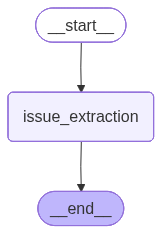

In [10]:
# Graph setup
graph=StateGraph(VaAnalysisState)

graph.add_node(issue_extraction,"issue_extraction")

graph.add_edge(START,"issue_extraction")

compiled_graph=graph.compile()

compiled_graph

In [ ]:
results=compiled_graph.invoke({
    'messages':[HumanMessage(content=jenkins_output_raw_text)]
})

In [ ]:
pprint(results.get("messages")[-1].content)

('{"messages":[],"issue_list":[{"issue_category":"VA","detailed_issue":"pom.xml '
 'includes vulnerable Logback components:\\n- ch.qos.logback:logback-classic '
 'CVE-2023-6378 (HIGH) installed 1.2.12, fixed 1.3.12/1.4.12/1.2.13\\n- '
 'ch.qos.logback:logback-core has related CVE-2023-6481 (serialization '
 'vulnerability in logback receiver) (severity not shown for the core line in '
 'the log; treated as HIGH-impact per title)","initial_fix":"Upgrade Logback '
 'to the fixed versions indicated by the report (at minimum '
 'ch.qos.logback:logback-classic -> 1.2.13 or 1.3.12 or 1.4.12; ensure '
 'logback-core is upgraded consistently to a version that fixes '
 'CVE-2023-6481).","bom_friendly_fix":"In your dependency management (or '
 'direct dependencies), set explicit versions for both logback-classic and '
 'logback-core to the same fixed release train (e.g., 1.4.12+). Re-run '
 'dependency scan to confirm the CVEs are '
 'removed."},{"issue_category":"VA","detailed_issue":"pom.xml i

class VaAnalysisState(TypedDict):
    messages:list[BaseMessage]
    issue_list:list[str]

class DetailedIssue(TypedDict):
    issue_category:Literal["VA","OTHER"]
    detailed_issue:str
    initial_fix:str
    bom_friendly_fix:str